In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import datetime
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.models import Model

In [2]:
#read CSV file
production_df=pd.read_csv("Data/combined_output.csv")
process_df=pd.read_csv("Data/combined_output_proc.csv")

In [3]:
# Convert the 'Date' column to datetime format
#production_df['Date'] = pd.to_datetime(production_df['Date'], format='%d/%m/%Y')
#process_df['Date'] = pd.to_datetime(process_df['Date'], format='%d/%m/%Y')




In [4]:
columns=process_df.columns
columns

Index(['Status', 'Part', 'Process', 'Employee', 'Date', 'Time', 'AV Wash',
       'VYA - Batch', 'VFX - Yeast Vat', 'Code', 'VFX - Feed TS',
       'VFX - Feed SS', 'VFX - Feed IS', 'VFX - Feed Setting',
       'VFX - Beer Recycle Setting', 'VFX - Water Setting', 'VFX - Cream TS',
       'VFX - Cream SS', 'VFX - Cream IS', 'VYA - Papain Batch',
       'VYA - Papain added', 'VYA - Clerol batch', 'VYA - Vaccum Salt Added',
       'VYA - Bag Salt Batch', 'VYA - Bag Salt Added', 'VYA - 1st pH',
       'VYA - Post heat duration', 'VYA - Final Volume', 'VMBX - Auto TS',
       'VMBX - Auto SS', 'VMBX - Auto IS', 'VMBX - Auto Yield',
       'VMBX - Auto Feed', 'VMBX - Water Rate', 'VMBX - Res Recycle',
       'VMBX - Ext Flowrate', 'VMBX - Ext TS', 'VMBX - Ext SS',
       'VMBX - Ext IS', 'VMBX - Res TS', 'VMBX - Res SS', 'VMBX - Res IS',
       'VMBX - H.Residue TS', 'VMBX - H.Residue SS', 'VMBX - H.Residue IS',
       'VMBX - RISC%', 'VMBX - Res Vat', 'Code.1', 'VMBX - Res Batch',
       'V

In [5]:
# Combine "Date" and "Time" into a single datetime column
production_df['Datetime'] = pd.to_datetime(production_df['Date'] + ' ' + production_df['Time'], format='%d/%m/%Y %H:%M:%S')

# Round the time to the nearest hour to group by hour
production_df['Datetime'] = production_df['Datetime'].dt.floor('h')

# Pivot the table so that each product type appears as a column, with the corresponding yeast weight
production_pivot_df = production_df.pivot_table(index='Datetime', columns='Part', values='VYP - Yeast Weight', aggfunc='sum').reset_index()

# Display the result to the user
production_pivot_df.head(10)

Part,Datetime,Yeast - BRD,Yeast - BRN,Yeast - FMX
0,2019-10-29 02:00:00,1257.50,NaN,NaN
1,2019-10-29 03:00:00,789.00,NaN,NaN
2,2019-10-29 04:00:00,1103.50,NaN,NaN
3,2019-10-29 05:00:00,638.75,NaN,NaN
4,2019-10-29 07:00:00,618.50,NaN,NaN
5,2019-10-29 08:00:00,1248.75,NaN,NaN
6,2019-10-29 09:00:00,611.50,NaN,NaN
7,2019-10-29 10:00:00,1242.00,NaN,NaN
8,2019-10-29 11:00:00,623.75,NaN,NaN
9,2019-10-29 12:00:00,627.75,NaN,152.5


In [6]:
process_df.columns

Index(['Status', 'Part', 'Process', 'Employee', 'Date', 'Time', 'AV Wash',
       'VYA - Batch', 'VFX - Yeast Vat', 'Code', 'VFX - Feed TS',
       'VFX - Feed SS', 'VFX - Feed IS', 'VFX - Feed Setting',
       'VFX - Beer Recycle Setting', 'VFX - Water Setting', 'VFX - Cream TS',
       'VFX - Cream SS', 'VFX - Cream IS', 'VYA - Papain Batch',
       'VYA - Papain added', 'VYA - Clerol batch', 'VYA - Vaccum Salt Added',
       'VYA - Bag Salt Batch', 'VYA - Bag Salt Added', 'VYA - 1st pH',
       'VYA - Post heat duration', 'VYA - Final Volume', 'VMBX - Auto TS',
       'VMBX - Auto SS', 'VMBX - Auto IS', 'VMBX - Auto Yield',
       'VMBX - Auto Feed', 'VMBX - Water Rate', 'VMBX - Res Recycle',
       'VMBX - Ext Flowrate', 'VMBX - Ext TS', 'VMBX - Ext SS',
       'VMBX - Ext IS', 'VMBX - Res TS', 'VMBX - Res SS', 'VMBX - Res IS',
       'VMBX - H.Residue TS', 'VMBX - H.Residue SS', 'VMBX - H.Residue IS',
       'VMBX - RISC%', 'VMBX - Res Vat', 'Code.1', 'VMBX - Res Batch',
       'V

In [7]:

# Combine "Date" and "Time" into a single datetime column
process_df['Datetime'] = pd.to_datetime(process_df['Date'] + ' ' + process_df['Time'], format='%d/%m/%Y %H:%M:%S')

# Round the time to the nearest hour
process_df['Datetime'] = process_df['Datetime'].dt.floor('h')

# Select the relevant columns: Part, Datetime, and the production metrics
relevant_columns = ['Datetime', 'Part', 'VMBX - Auto Yield', 'VMBX - Auto Feed', 'VYA - Papain added',
 'VYA - Final Volume', 'VFX - Feed SS', 'VMBX - Res IS/TS (%)']
# Filter the dataframe for these columns
process_df_filtered = process_df[relevant_columns]

# Pivot the table to have one column per product for each metric
pivot_yield = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VMBX - Auto Yield', aggfunc='sum').reset_index()
pivot_vmbxfeed = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VMBX - Auto Feed', aggfunc='sum').reset_index()
pivot_papain = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VYA - Papain added', aggfunc='mean').reset_index()
pivot_vol = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VYA - Final Volume', aggfunc='sum').reset_index()
pivot_vfxfeed = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VFX - Feed SS', aggfunc='sum').reset_index()
pivot_ists = process_df_filtered.pivot_table(index='Datetime', columns='Part', values='VMBX - Res IS/TS (%)', aggfunc='mean').reset_index()

# Merge the three pivoted dataframes on the Datetime
process_merged_df = pd.merge(pivot_yield, pivot_vmbxfeed, on='Datetime', suffixes=('_Yield', '_VMBX_Feed'))
process_merged_df = pd.merge(process_merged_df, pivot_papain, on='Datetime', suffixes=('', '_Papain'))
process_merged_df = pd.merge(process_merged_df, pivot_vol, on='Datetime', suffixes=('', '_Volume'))
process_merged_df = pd.merge(process_merged_df, pivot_vfxfeed, on='Datetime', suffixes=('', '_VFX_Feed'))
process_merged_df = pd.merge(process_merged_df, pivot_ists, on='Datetime', suffixes=('', '_IS/TS'))

# Rename the columns by adding '_proc' to the columns 'Yeast - BRD', 'Yeast - BRN', 'Yeast - FMX'
process_merged_df = process_merged_df.rename(columns={
    'Yeast - BRD': 'Yeast - BRD_Papain',
    'Yeast - BRN': 'Yeast - BRN_Papain',
    'Yeast - FMX': 'Yeast - FMX_Papain'
})
# Keep only the columns of interest
columns_to_keep = ['Datetime', 'Yeast - BRD_Yield', 'Yeast - BRD_VMBX_Feed', 'Yeast - BRD_Papain', 'Yeast - BRD_Volume', 
                   'Yeast - BRD_VFX_Feed', 'Yeast - BRD_IS/TS', 'Yeast - BRN_Yield', 'Yeast - BRN_VMBX_Feed', 'Yeast - BRN_Papain', 'Yeast - BRN_Volume', 
                   'Yeast - BRN_VFX_Feed', 'Yeast - BRN_IS/TS', 'Yeast - FMX_Yield', 'Yeast - FMX_VMBX_Feed', 'Yeast - FMX_Papain', 'Yeast - FMX_Volume', 
                   'Yeast - FMX_VFX_Feed', 'Yeast - FMX_IS/TS']

# Filter the dataframe to keep only the necessary columns
process_filtered_df = process_merged_df[columns_to_keep]


# Display the updated dataframe
process_filtered_df.head()


Part,Datetime,Yeast - BRD_Yield,Yeast - BRD_VMBX_Feed,Yeast - BRD_Papain,Yeast - BRD_Volume,Yeast - BRD_VFX_Feed,Yeast - BRD_IS/TS,Yeast - BRN_Yield,Yeast - BRN_VMBX_Feed,Yeast - BRN_Papain,Yeast - BRN_Volume,Yeast - BRN_VFX_Feed,Yeast - BRN_IS/TS,Yeast - FMX_Yield,Yeast - FMX_VMBX_Feed,Yeast - FMX_Papain,Yeast - FMX_Volume,Yeast - FMX_VFX_Feed,Yeast - FMX_IS/TS
0,2019-09-30 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.61,11000.0,2.1,20200.0,3.22,80.17,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-09-30 13:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.61,11500.0,2.0,19800.0,3.22,80.98,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-09-30 15:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.61,12000.0,1.9,18400.0,3.22,80.79,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-10-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.69,11000.0,4.0,19900.0,0.0,80.940
4,2019-10-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.38,22000.0,3.0,37300.0,0.0,80.215


In [8]:
pivot_papain

Part,Datetime,Yeast - BRD,Yeast - BRN,Yeast - FMX
0,2019-09-30 11:00:00,NaN,2.1,NaN
1,2019-09-30 13:00:00,NaN,2.0,NaN
2,2019-09-30 15:00:00,NaN,1.9,NaN
3,2019-10-01 01:00:00,NaN,NaN,4.0
4,2019-10-01 02:00:00,NaN,NaN,3.0
...,...,...,...,...
747,2020-06-30 01:00:00,NaN,NaN,4.0
748,2020-06-30 09:00:00,NaN,NaN,5.6
749,2020-06-30 10:00:00,NaN,NaN,5.6
750,2020-06-30 13:00:00,NaN,NaN,4.0


In [9]:
process_merged_df

Part,Datetime,Yeast - BRD_Yield,Yeast - BRN_Yield,Yeast - FMX_Yield,Yeast - BRD_VMBX_Feed,Yeast - BRN_VMBX_Feed,Yeast - FMX_VMBX_Feed,Yeast - BRD_Papain,Yeast - BRN_Papain,Yeast - FMX_Papain,Yeast - BRD_Volume,Yeast - BRN_Volume,Yeast - FMX_Volume,Yeast - BRD_VFX_Feed,Yeast - BRN_VFX_Feed,Yeast - FMX_VFX_Feed,Yeast - BRD_IS/TS,Yeast - BRN_IS/TS,Yeast - FMX_IS/TS
0,2019-09-30 11:00:00,NaN,0.61,NaN,NaN,11000.0,NaN,NaN,2.1,NaN,NaN,20200.0,NaN,NaN,3.22,NaN,NaN,80.17,NaN
1,2019-09-30 13:00:00,NaN,0.61,NaN,NaN,11500.0,NaN,NaN,2.0,NaN,NaN,19800.0,NaN,NaN,3.22,NaN,NaN,80.98,NaN
2,2019-09-30 15:00:00,NaN,0.61,NaN,NaN,12000.0,NaN,NaN,1.9,NaN,NaN,18400.0,NaN,NaN,3.22,NaN,NaN,80.79,NaN
3,2019-10-01 01:00:00,NaN,NaN,0.69,NaN,NaN,11000.0,NaN,NaN,4.0,NaN,NaN,19900.0,NaN,NaN,0.0,NaN,NaN,80.940
4,2019-10-01 02:00:00,NaN,NaN,1.38,NaN,NaN,22000.0,NaN,NaN,3.0,NaN,NaN,37300.0,NaN,NaN,0.0,NaN,NaN,80.215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,2020-06-30 01:00:00,NaN,NaN,0.68,NaN,NaN,8600.0,NaN,NaN,4.0,NaN,NaN,19400.0,NaN,NaN,0.0,NaN,NaN,89.740
722,2020-06-30 09:00:00,NaN,NaN,0.68,NaN,NaN,8600.0,NaN,NaN,5.6,NaN,NaN,20000.0,NaN,NaN,0.0,NaN,NaN,89.600
723,2020-06-30 10:00:00,NaN,NaN,0.68,NaN,NaN,6500.0,NaN,NaN,5.6,NaN,NaN,20101.0,NaN,NaN,0.0,NaN,NaN,91.480
724,2020-06-30 13:00:00,NaN,NaN,0.66,NaN,NaN,6800.0,NaN,NaN,4.0,NaN,NaN,14954.0,NaN,NaN,0.0,NaN,NaN,92.960


In [10]:


# Merge the production and the process files
merged_df = pd.merge(process_filtered_df,production_pivot_df,  left_on='Datetime', right_on='Datetime')




In [11]:
# Set the 'Datetime' column as the index (if not already set)
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])  # Ensure the Datetime column is in datetime format
merged_df.set_index('Datetime', inplace=True)

#Save the result to a new CSV file
output_file = "Data/daily_sum_weight_merg_2.csv"
merged_df.to_csv(output_file, index=True)


<Figure size 1000x600 with 0 Axes>

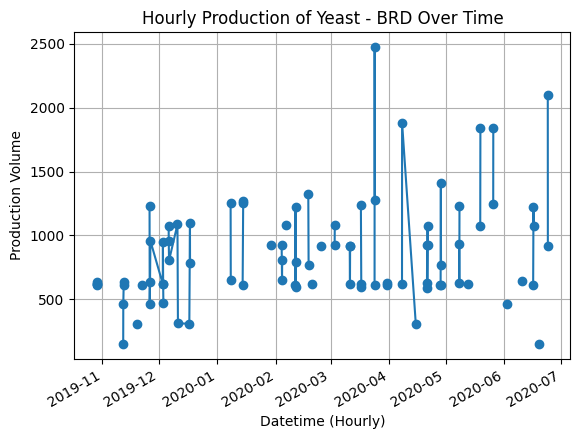

<Figure size 1000x600 with 0 Axes>

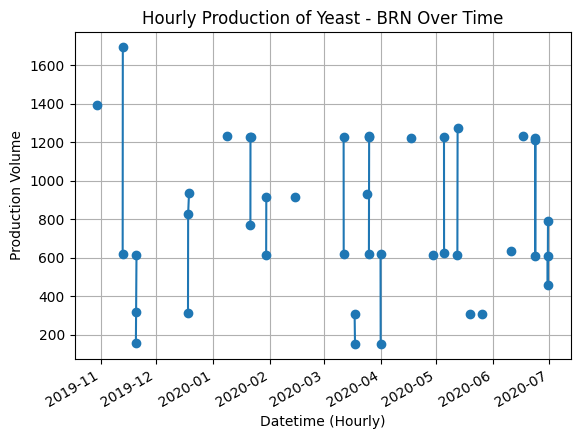

<Figure size 1000x600 with 0 Axes>

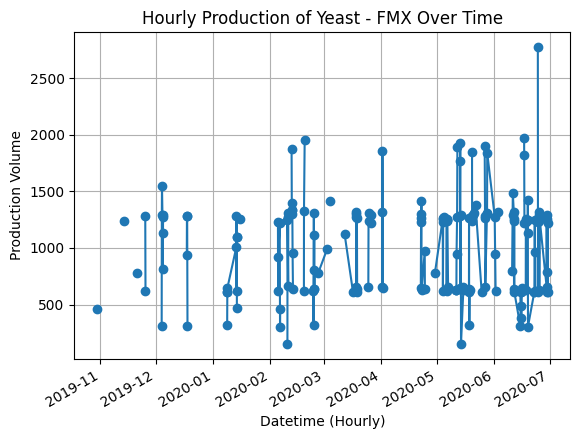

In [12]:
# Create individual plots for each product
products = ['Yeast - BRD', 'Yeast - BRN', 'Yeast - FMX']

for product in products:
    plt.figure(figsize=(10, 6))
    merged_df[[product]].plot(kind='line', marker='o', legend=False)
    plt.title(f'Hourly Production of {product} Over Time')
    plt.xlabel('Datetime (Hourly)')
    plt.ylabel('Production Volume')
    plt.grid(True)
    plt.show()

In [13]:
file_path = "Data/daily_sum_weight_merg_2.csv"



In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Load and preprocess the data
df = pd.read_csv(file_path)
df.fillna(0, inplace=True)
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

# Select target columns and additional input features
target_columns = ['Yeast - BRD', 'Yeast - BRN', 'Yeast - FMX']
additional_features = ['Yeast - BRD_Yield', 'Yeast - BRD_VMBX_Feed', 'Yeast - BRD_Papain', 'Yeast - BRD_Volume', 
                   'Yeast - BRD_VFX_Feed', 'Yeast - BRD_IS/TS', 'Yeast - BRN_Yield', 'Yeast - BRN_VMBX_Feed', 'Yeast - BRN_Papain', 'Yeast - BRN_Volume', 
                   'Yeast - BRN_VFX_Feed', 'Yeast - BRN_IS/TS', 'Yeast - FMX_Yield', 'Yeast - FMX_VMBX_Feed', 'Yeast - FMX_Papain', 'Yeast - FMX_Volume', 
                   'Yeast - FMX_VFX_Feed', 'Yeast - FMX_IS/TS']

# Separate the target data and additional input data
target_data = df[target_columns].values
additional_input_data = df[additional_features].values

# Scaling the target columns and additional features separately
target_scaler = MinMaxScaler(feature_range=(0, 1))
additional_scaler = MinMaxScaler(feature_range=(0, 1))

scaled_target_data = target_scaler.fit_transform(target_data)
scaled_additional_data = additional_scaler.fit_transform(additional_input_data)

# Create dataset with look-back
def create_dataset_for_xgboost(dataset, additional_data, look_back):
    X, Y, additional = [], [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back)])  # Target columns as input
        Y.append(dataset[i + look_back])      # Predict the next timestep of the target
        additional.append(additional_data[i + look_back])  # Additional features for the last timestep
    return np.array(X), np.array(Y), np.array(additional)

look_back = 30
X, Y, additional = create_dataset_for_xgboost(scaled_target_data, scaled_additional_data, look_back)

# Reshape input to be [samples, time steps, features]
X = np.reshape(X, (X.shape[0], look_back, X.shape[2]))

# Split into train and test sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]
additional_train, additional_test = additional[:train_size], additional[train_size:]

# Flatten the inputs for XGBoost
X_train_flat = np.array([np.concatenate([x.flatten(), add]) for x, add in zip(X_train, additional_train)])
X_test_flat = np.array([np.concatenate([x.flatten(), add]) for x, add in zip(X_test, additional_test)])

# Train an XGBoost model for each target variable
models = []
for i in range(Y_train.shape[1]):  # Iterate over each target column
    model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=5)
    model.fit(X_train_flat, Y_train[:, i])
    models.append(model)

# Make predictions
test_predictions = np.column_stack([model.predict(X_test_flat) for model in models])

scaled_test_predictions = target_scaler.inverse_transform(test_predictions)
scaled_Y_test = target_scaler.inverse_transform(Y_test)

# Compute error


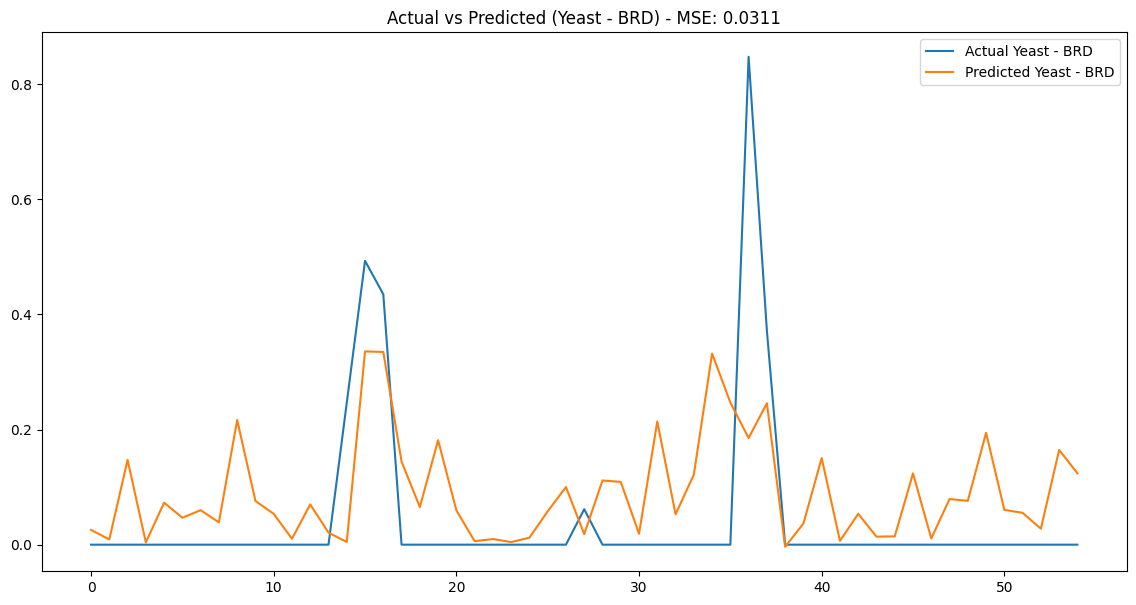

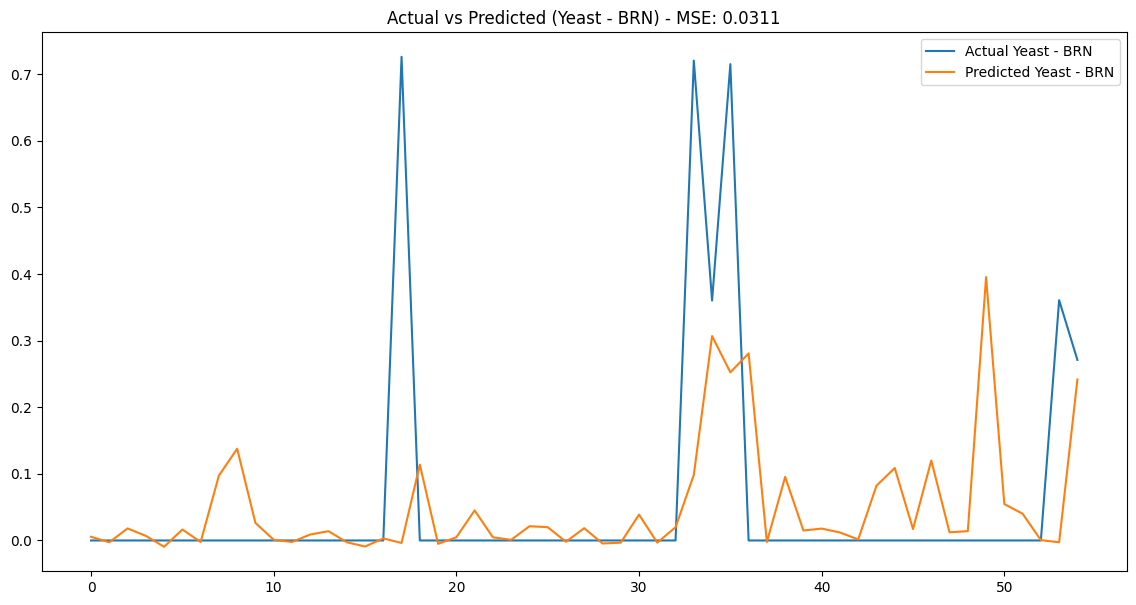

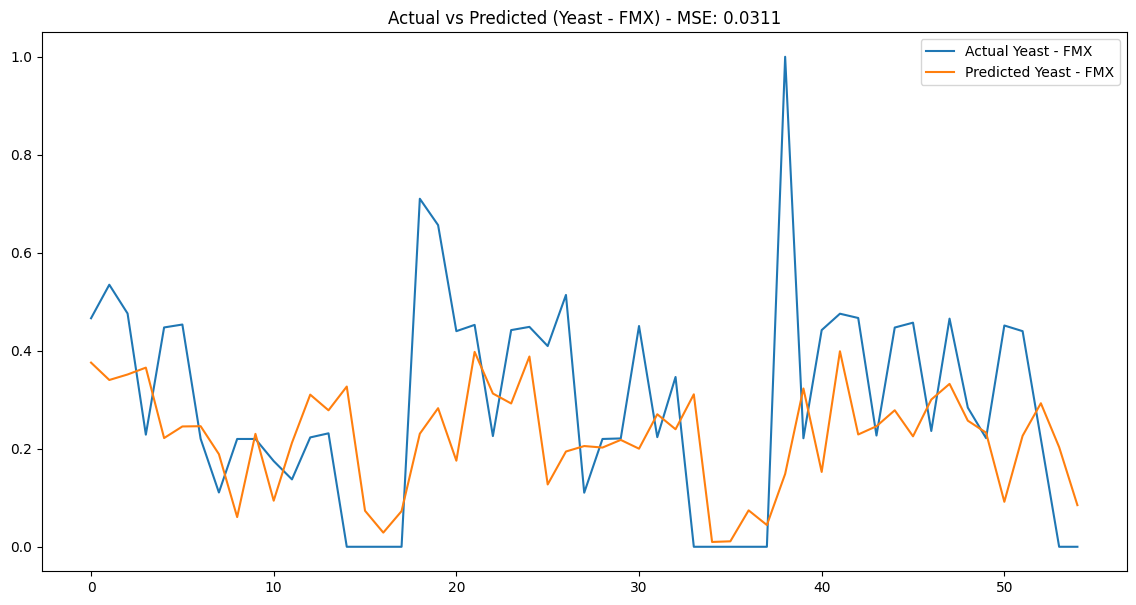

In [17]:
mse = mean_squared_error(Y_test, test_predictions)

# Plot actual vs predicted for each target column
plt.figure(figsize=(14, 7))
plt.plot(Y_test[:, 0], label='Actual Yeast - BRD')
plt.plot(test_predictions[:, 0], label='Predicted Yeast - BRD')
plt.title(f'Actual vs Predicted (Yeast - BRD) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(Y_test[:, 1], label='Actual Yeast - BRN')
plt.plot(test_predictions[:, 1], label='Predicted Yeast - BRN')
plt.title(f'Actual vs Predicted (Yeast - BRN) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(Y_test[:, 2], label='Actual Yeast - FMX')
plt.plot(test_predictions[:, 2], label='Predicted Yeast - FMX')
plt.title(f'Actual vs Predicted (Yeast - FMX) - MSE: {mse:.4f}')
plt.legend()
plt.show()



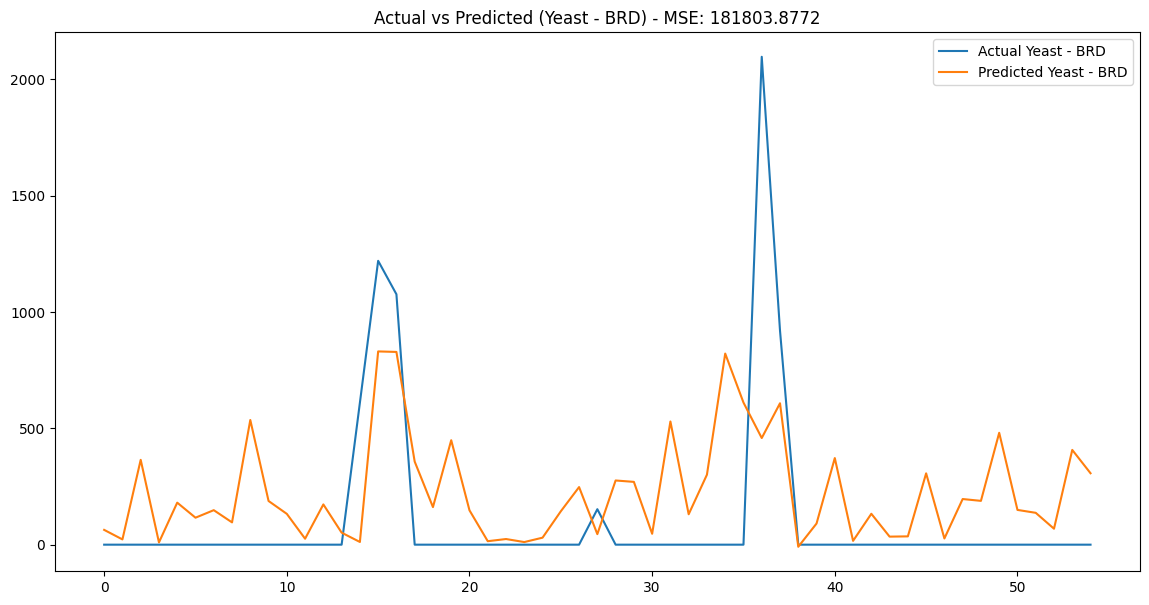

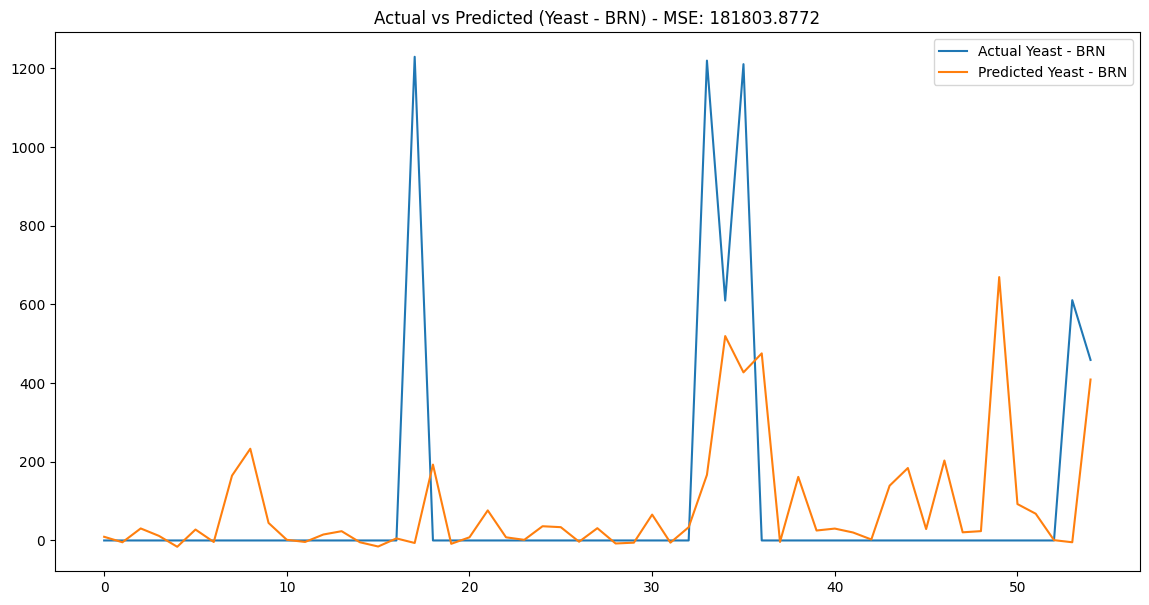

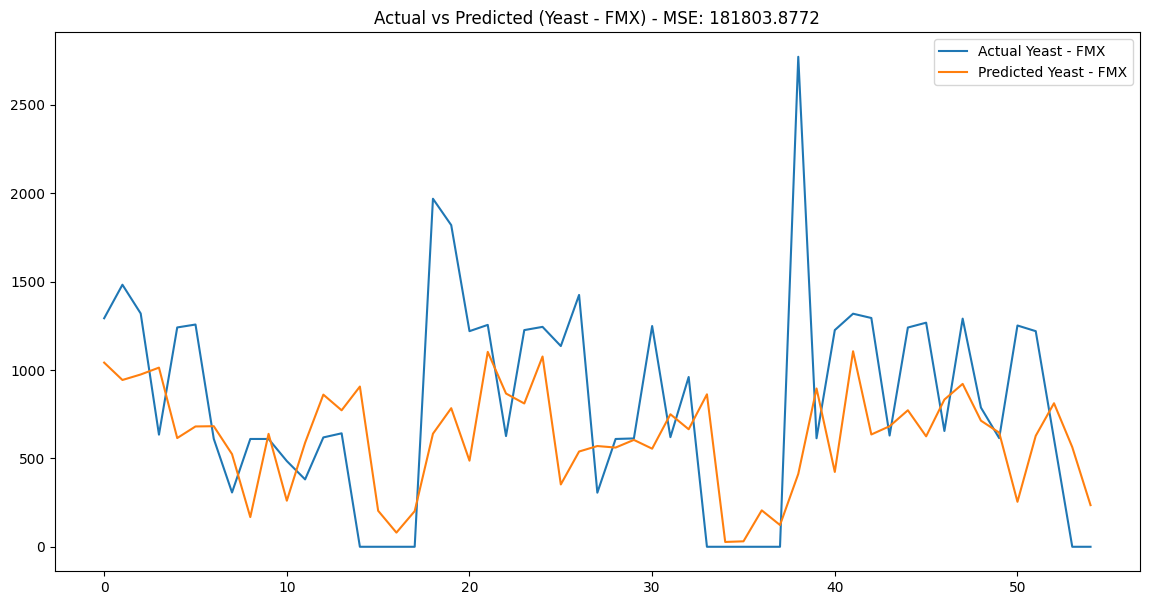

In [18]:
mse = mean_squared_error(scaled_Y_test, scaled_test_predictions)

# Plot actual vs predicted for each target column
plt.figure(figsize=(14, 7))
plt.plot(scaled_Y_test[:, 0], label='Actual Yeast - BRD')
plt.plot(scaled_test_predictions[:, 0], label='Predicted Yeast - BRD')
plt.title(f'Actual vs Predicted (Yeast - BRD) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(scaled_Y_test[:, 1], label='Actual Yeast - BRN')
plt.plot(scaled_test_predictions[:, 1], label='Predicted Yeast - BRN')
plt.title(f'Actual vs Predicted (Yeast - BRN) - MSE: {mse:.4f}')
plt.legend()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(scaled_Y_test[:, 2], label='Actual Yeast - FMX')
plt.plot(scaled_test_predictions[:, 2], label='Predicted Yeast - FMX')
plt.title(f'Actual vs Predicted (Yeast - FMX) - MSE: {mse:.4f}')
plt.legend()
plt.show()



In [16]:

# Extract the dates for the test data (this assumes your DataFrame has 'Datetime' as the index)
dates = df.index[-len(scaled_Y_test):]  # Adjust the range based on your test set size

# Create the DataFrame with Date & Hour, Current (Actual), and Predicted values
output_df = pd.DataFrame({
    'Date & hour': dates,
    'Current Yeast - BRD': scaled_Y_test[:, 0],
    'Predicted Yeast - BRD': scaled_test_predictions[:, 0],
    'Current Yeast - BRN': scaled_Y_test[:, 1],
    'Predicted Yeast - BRN': scaled_test_predictions[:, 1],
    'Current Yeast - FMX': scaled_Y_test[:, 2],
    'Predicted Yeast - FMX': scaled_test_predictions[:, 2],
})

# Save the DataFrame to a CSV file
output_file_path = 'Data/xgboost_predictions_v2_output-hours.csv'  # Change this path if needed
output_df.to_csv(output_file_path, index=False)
